# Análisis exploratorio de datos.
## Grupo 2

### Importación de datos

In [1]:
import pandas as pd
import numpy as np
import random

### Importación de datos

In [2]:
df = pd.read_csv('train.csv', index_col=0)
df.head(3)

,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,JPX_RSS3_Rubber_Futures_Open,...,FX_GBPCAD,FX_CADCHF,FX_NZDCAD,FX_NZDCHF,FX_ZAREUR,FX_NOKGBP,FX_NOKCHF,FX_ZARCHF,FX_NOKJPY,FX_ZARGBP
date_id,,,,,,,,,,,,,,,,,,,,,
0,2264.5,7205.0,2570.0,3349.0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.699987,0.776874,0.888115,0.689954,0.066653,0.090582,0.119630,0.078135,13.822740,0.059163
1,2228.0,7147.0,2579.0,3327.0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.695279,0.778682,0.889488,0.692628,0.067354,0.091297,0.120520,0.079066,13.888146,0.059895
2,2250.0,7188.5,2587.0,3362.0,4684.0,4691.0,4684.0,3363.0,3367.0,207.0,...,1.692724,0.780186,0.894004,0.697490,0.067394,0.091478,0.120809,0.079287,13.983675,0.060037


In [3]:
df_labels = pd.read_csv('train_labels.csv', index_col=0)
df_labels.head(3)

,target_0,target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,target_9,...,target_414,target_415,target_416,target_417,target_418,target_419,target_420,target_421,target_422,target_423
date_id,,,,,,,,,,,,,,,,,,,,,
0,0.005948,-0.002851,-0.004675,-0.000639,NaN,NaN,-0.006729,0.006066,NaN,0.003446,...,NaN,0.021239,-0.005595,NaN,-0.004628,0.033793,NaN,0.038234,NaN,0.027310
1,0.005783,-0.024118,-0.007052,-0.018955,-0.031852,-0.019452,0.003002,-0.006876,-0.002042,0.021284,...,0.003377,0.021372,-0.001517,0.012846,0.010547,0.030527,-0.000764,0.025021,0.003548,0.020940
2,0.001048,0.023836,-0.008934,-0.022060,NaN,NaN,0.037449,0.007658,NaN,-0.026844,...,-0.006712,0.009308,0.001857,-0.012761,-0.002345,0.017529,-0.005394,0.004835,-0.009075,0.001706


In [4]:
labels = pd.read_csv('target_pairs.csv')
labels.head(3)

,target,lag,pair
0,target_0,1,US_Stock_VT_adj_close
1,target_1,1,LME_PB_Close - US_Stock_VT_adj_close
2,target_2,1,LME_CA_Close - LME_ZS_Close


### Tamaño de los conjuntos de datos.

In [5]:
print(df.shape)
print(df_labels.shape)
print(labels.shape)

(1961, 557)
(1961, 424)
(424, 3)


Los conjuntos df y df_labels tienen la misma cantidad de filas, pero no columnas.  
El conjunto df_labels tiene la misma cantidad de columnas que la cantidad de filas del conjunto labels.  
Esto no es coincidencia, en los siguientes incisos se mostrará la relación.

### Comprobando la relación de los índices de df y df_labels.

In [6]:
(df.index == df_labels.index).all()

np.True_

Esto indica que df y df_labels están relacionados mediante el mismo índice date_id.

### Comprobando la relacón entre columnas de df_labes con las filas de labels.

In [7]:
(np.array(df_labels.columns) == np.array(labels['target'])).all()

np.True_

Las filas del conjunto labels dan explicación de cómo se construye el cojunto df_labels a partir del conjunto df.

### Observando valores faltantes.

In [8]:
df.isna().sum()[df.isna().sum() > 0]

LME_AH_Close                   51
LME_CA_Close                   51
LME_PB_Close                   51
LME_ZS_Close                   51
JPX_Gold_Mini_Futures_Open    116
                             ... 
US_Stock_X_adj_volume          92
US_Stock_XLB_adj_volume        67
US_Stock_XLE_adj_volume        67
US_Stock_XOM_adj_volume        67
US_Stock_YINN_adj_volume       67
Length: 519, dtype: int64

In [9]:
df_labels.isna().sum()[df_labels.isna().sum() > 0]

target_0      134
target_1      177
target_2       86
target_3       86
target_4      288
             ... 
target_419    102
target_420    344
target_421    193
target_422    220
target_423    193
Length: 422, dtype: int64

Hay muchos valores faltantes. Al ser datos secuenciales se usará interpolación para reemplazar los datos faltantes, tomando los dos períodos de tiempo con datos como los límites de la recta que se usará para el reemplazo de los datos.

### Tipos de variables.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1961 entries, 0 to 1960
Columns: 557 entries, LME_AH_Close to FX_ZARGBP
dtypes: float64(557)
memory usage: 8.3 MB


In [11]:
df_labels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1961 entries, 0 to 1960
Columns: 424 entries, target_0 to target_423
dtypes: float64(424)
memory usage: 6.4 MB


In [12]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  424 non-null    object
 1   lag     424 non-null    int64 
 2   pair    424 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.1+ KB


En los conjuntos df y df_labels, todas las variables son del tipo flotante, a excepción del índice que es entera.  
En el conjunto labels se tienen dos tipo object, una que indica la relación con el conjunto df_label y otra que explica como formar la variable de ese mismo conjunto con las variables. Además, tiene una variable que indica el desplazamiento temporal sobre el cual se hará la diferencia.

### Viendo las estadísticas de algunas columnas.

In [13]:
random.seed(0)
muestra_columnas_df = random.sample(list(df.columns), 10)
df[muestra_columnas_df].describe()

,US_Stock_SLV_adj_close,US_Stock_BCS_adj_volume,JPX_Platinum_Mini_Futures_open_interest,US_Stock_FXI_adj_low,FX_EURAUD,US_Stock_TRGP_adj_volume,US_Stock_VWO_adj_close,US_Stock_VCIT_adj_low,US_Stock_SLB_adj_volume,US_Stock_HES_adj_close
count,1894.000000,1.894000e+03,1845.000000,1894.000000,1961.000000,1.894000e+03,1894.000000,1894.000000,1.894000e+03,1889.000000
mean,20.723643,7.581876e+06,1019.606504,34.075453,1.611192,2.141732e+06,39.304192,74.665816,1.213022e+07,91.886647
std,5.041229,7.152220e+06,461.290896,6.428836,0.065779,1.966738e+06,4.852469,5.492945,6.145386e+06,41.094551
min,11.210000,8.270000e+05,75.000000,19.961400,1.431856,3.726730e+05,26.122000,64.700000,3.077628e+06,26.951300
25%,16.050000,3.123644e+06,705.000000,28.103125,1.573027,1.363230e+06,35.834125,70.574725,8.280916e+06,55.046500
50%,21.010000,5.448052e+06,987.000000,35.577350,1.614303,1.736846e+06,38.280550,75.084800,1.082127e+07,78.595300
75%,23.830000,1.005262e+07,1312.000000,38.668650,1.645211,2.354156e+06,43.724975,80.039175,1.420376e+07,135.986500
max,35.720000,1.476120e+08,5064.000000,50.752700,1.886723,4.903322e+07,51.377784,83.017600,8.614796e+07,162.812800


In [14]:
random.seed(0)
muestra_columnas_labels = random.sample(list(df_labels.columns), 10)
df_labels[muestra_columnas_labels].describe()

,target_197,target_388,target_215,target_20,target_132,target_261,target_248,target_207,target_401,target_155
count,1743.000000,1768.000000,1648.000000,1875.000000,1768.000000,1611.000000,1768.000000,1615.000000,1768.000000,1859.000000
mean,0.001040,-0.000964,-0.002047,0.000086,-0.000015,-0.000214,-0.000752,0.000407,-0.000970,-0.000186
std,0.023484,0.031342,0.024483,0.015585,0.031966,0.049342,0.040315,0.019017,0.031519,0.018165
min,-0.167510,-0.138604,-0.100159,-0.065950,-0.262895,-0.217348,-0.188306,-0.071815,-0.138864,-0.082675
25%,-0.013065,-0.020635,-0.018352,-0.009582,-0.019989,-0.029442,-0.023936,-0.010189,-0.021036,-0.010627
50%,-0.000057,-0.001053,-0.002421,0.000272,-0.000391,-0.000196,-0.000833,-0.000350,-0.001222,0.000168
75%,0.014881,0.017888,0.014357,0.009742,0.020163,0.029608,0.022085,0.010154,0.017585,0.010558
max,0.144684,0.208004,0.096413,0.073294,0.174982,0.230180,0.208757,0.140181,0.201521,0.112808


In [15]:
labels['lag'].value_counts()

lag
1    106
2    106
3    106
4    106
Name: count, dtype: int64

Muchas de las columnas del conjunto df tienen escalas enormes, mientras que las columnas del conjunto df_labels tienen escalas mucho más controladas (en la muestra entre -0.3 y 0.25). Esto debido a que, como se menciona en la página del concurso de Kaggle, los datos fueron operados con escalas logarítmicas para evitar problemas de escala al momento de entrenar modelos.  
La columna lag del conjunto labels muestra que se tienen desplazamientos entre 1 y 4 unidades temporales.

### Cruzando variables para explicar etiquetas.

In [25]:
labels[labels['target'] == 'target_1']

,target,lag,pair
1,target_1,1,LME_PB_Close - US_Stock_VT_adj_close


In [16]:
df_labels['target_1']

date_id
0      -0.002851
1      -0.024118
2       0.023836
3      -0.024618
4       0.005234
          ...   
1956   -0.004500
1957   -0.001036
1958   -0.002032
1959   -0.006335
1960    0.006502
Name: target_1, Length: 1961, dtype: float64

In [17]:
ret_1 = (np.log(df['LME_PB_Close'].shift(-1)) - np.log(df['LME_PB_Close']))
ret_2 = (np.log(df['US_Stock_VT_adj_close'].shift(-1)) - np.log(df['US_Stock_VT_adj_close']))
ret_1-ret_2

date_id
0      -0.003289
1      -0.002851
2      -0.024118
3       0.023836
4      -0.024618
          ...   
1956   -0.000225
1957   -0.004500
1958   -0.001036
1959   -0.002032
1960         NaN
Length: 1961, dtype: float64

In [26]:
labels[labels['target'] == 'target_0']

,target,lag,pair
0,target_0,1,US_Stock_VT_adj_close


In [18]:
df_labels['target_0']

date_id
0       0.005948
1       0.005783
2       0.001048
3       0.001700
4      -0.003272
          ...   
1956    0.002761
1957    0.011424
1958   -0.002654
1959    0.002124
1960   -0.005013
Name: target_0, Length: 1961, dtype: float64

In [19]:
np.log(df['US_Stock_VT_adj_close'].shift(-1))- np.log(df['US_Stock_VT_adj_close'])

date_id
0       0.006785
1       0.005948
2       0.005783
3       0.001048
4       0.001700
          ...   
1956    0.002461
1957    0.002761
1958    0.011424
1959   -0.002654
1960         NaN
Name: US_Stock_VT_adj_close, Length: 1961, dtype: float64

Podemos observar que a partir del conjunto df_labels puede ser formado por el conjunto labels, aunque el conjunto df_labels contiene más información, ya que las últimas dos filas no pueden ser obtenidas con la fórmula, mientras que la primera fila de la fórmula no aparece en el conjunto df_labels.

### Graficando el comportamiento de las variables (aplicando escala log).

<Axes: xlabel='date_id'>

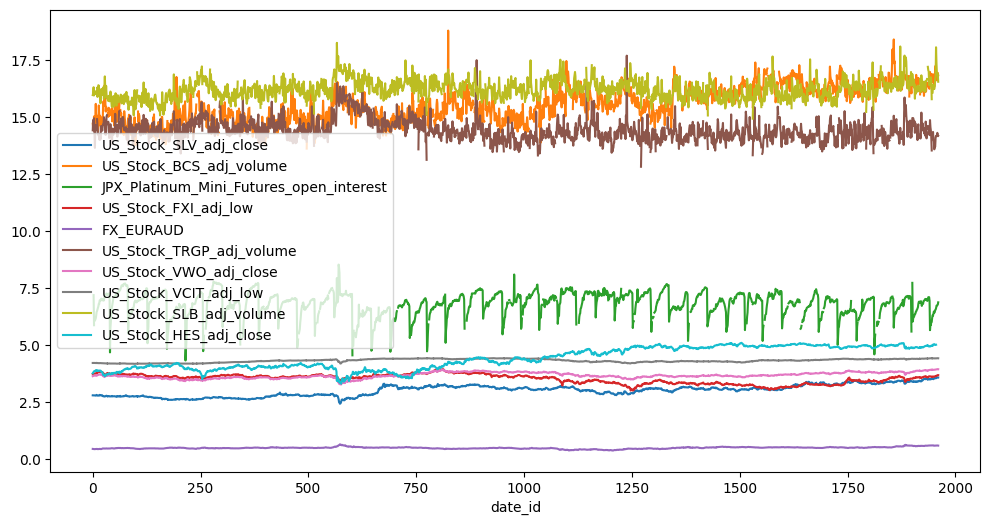

In [20]:
df_log = np.log(df[muestra_columnas_df])
df_log.iloc[:, :].plot(figsize=(12, 6))

<Axes: xlabel='date_id'>

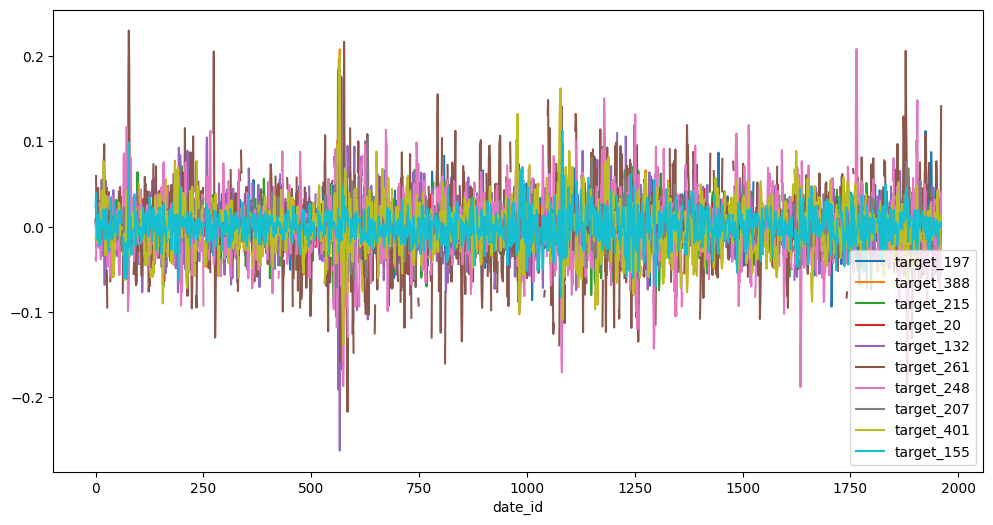

In [24]:
df_labels.loc[:, muestra_columnas_labels].plot(figsize=(12, 6))

En el primer gráfico podemos observar que escalar con log, permitió tener escalas mucho más manejables.  
En el segundo gráfico podemos observar que las targets de muestra están centradas alrededor de 0 y tienen escalas pequeñas, lo cual puede mejorar la capacidad predictiva y de generalización del modelo.